# Support Vector Machine Classification of Countries

# Objective

1. Classification of countries based on their per Capita GDP status (Low Income, Lower Middle, Upper Middle, High) with the given features.

# About the Data

We have a dataset from UNICEF with the following variables:
1. Country 
2. Government Revenue as a percentage of GDP
3. Overall expenditure as a percentage of GDP
4. Health Expenditure as a percentage of GDP
5. Education Expenditure as a percentage of GDP
6. Social protection Expenditure as a percentage of GDP
7. ODA inflow as percentage of GNI
8. GDP per capita
9. GDP per Capita Class ( Based on World Bank Classification i.e Low, Lower Middle, Upper Middle, Upper Income)

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [4]:
df = pd.read_csv('UNICEF data cleaned.csv')

In [5]:
df.head()

,Country,Govt Rev_GDP,Over All Expenditure_GDP,Health Expenditure_GDP,Education Expenditure_GDP,social protection expenditure_GDP,ODA inflow_GNI,GDP per Capita,GDP per Capita Class
0,Afghanistan,13.0,21.8,0.7,4.3,1.4,26.8,415.707417,Low Income
1,Albania,19.3,11.1,2.9,2.7,1.9,1.7,8575.171134,Upper Middle Income
2,Algeria,23.1,16.9,3.3,6.3,2.3,0.1,5364.027950,Upper Middle Income
3,Andorra,26.0,19.8,6.2,2.7,1.2,0.0,46812.448449,High Income
4,Angola,21.8,6.4,1.7,2.3,0.5,0.1,2308.159767,Lower Middle Income


# EDA
We have done a detailed EDA of this dataset in the project of K-Nearest Neighbour
We will do some basic work here.

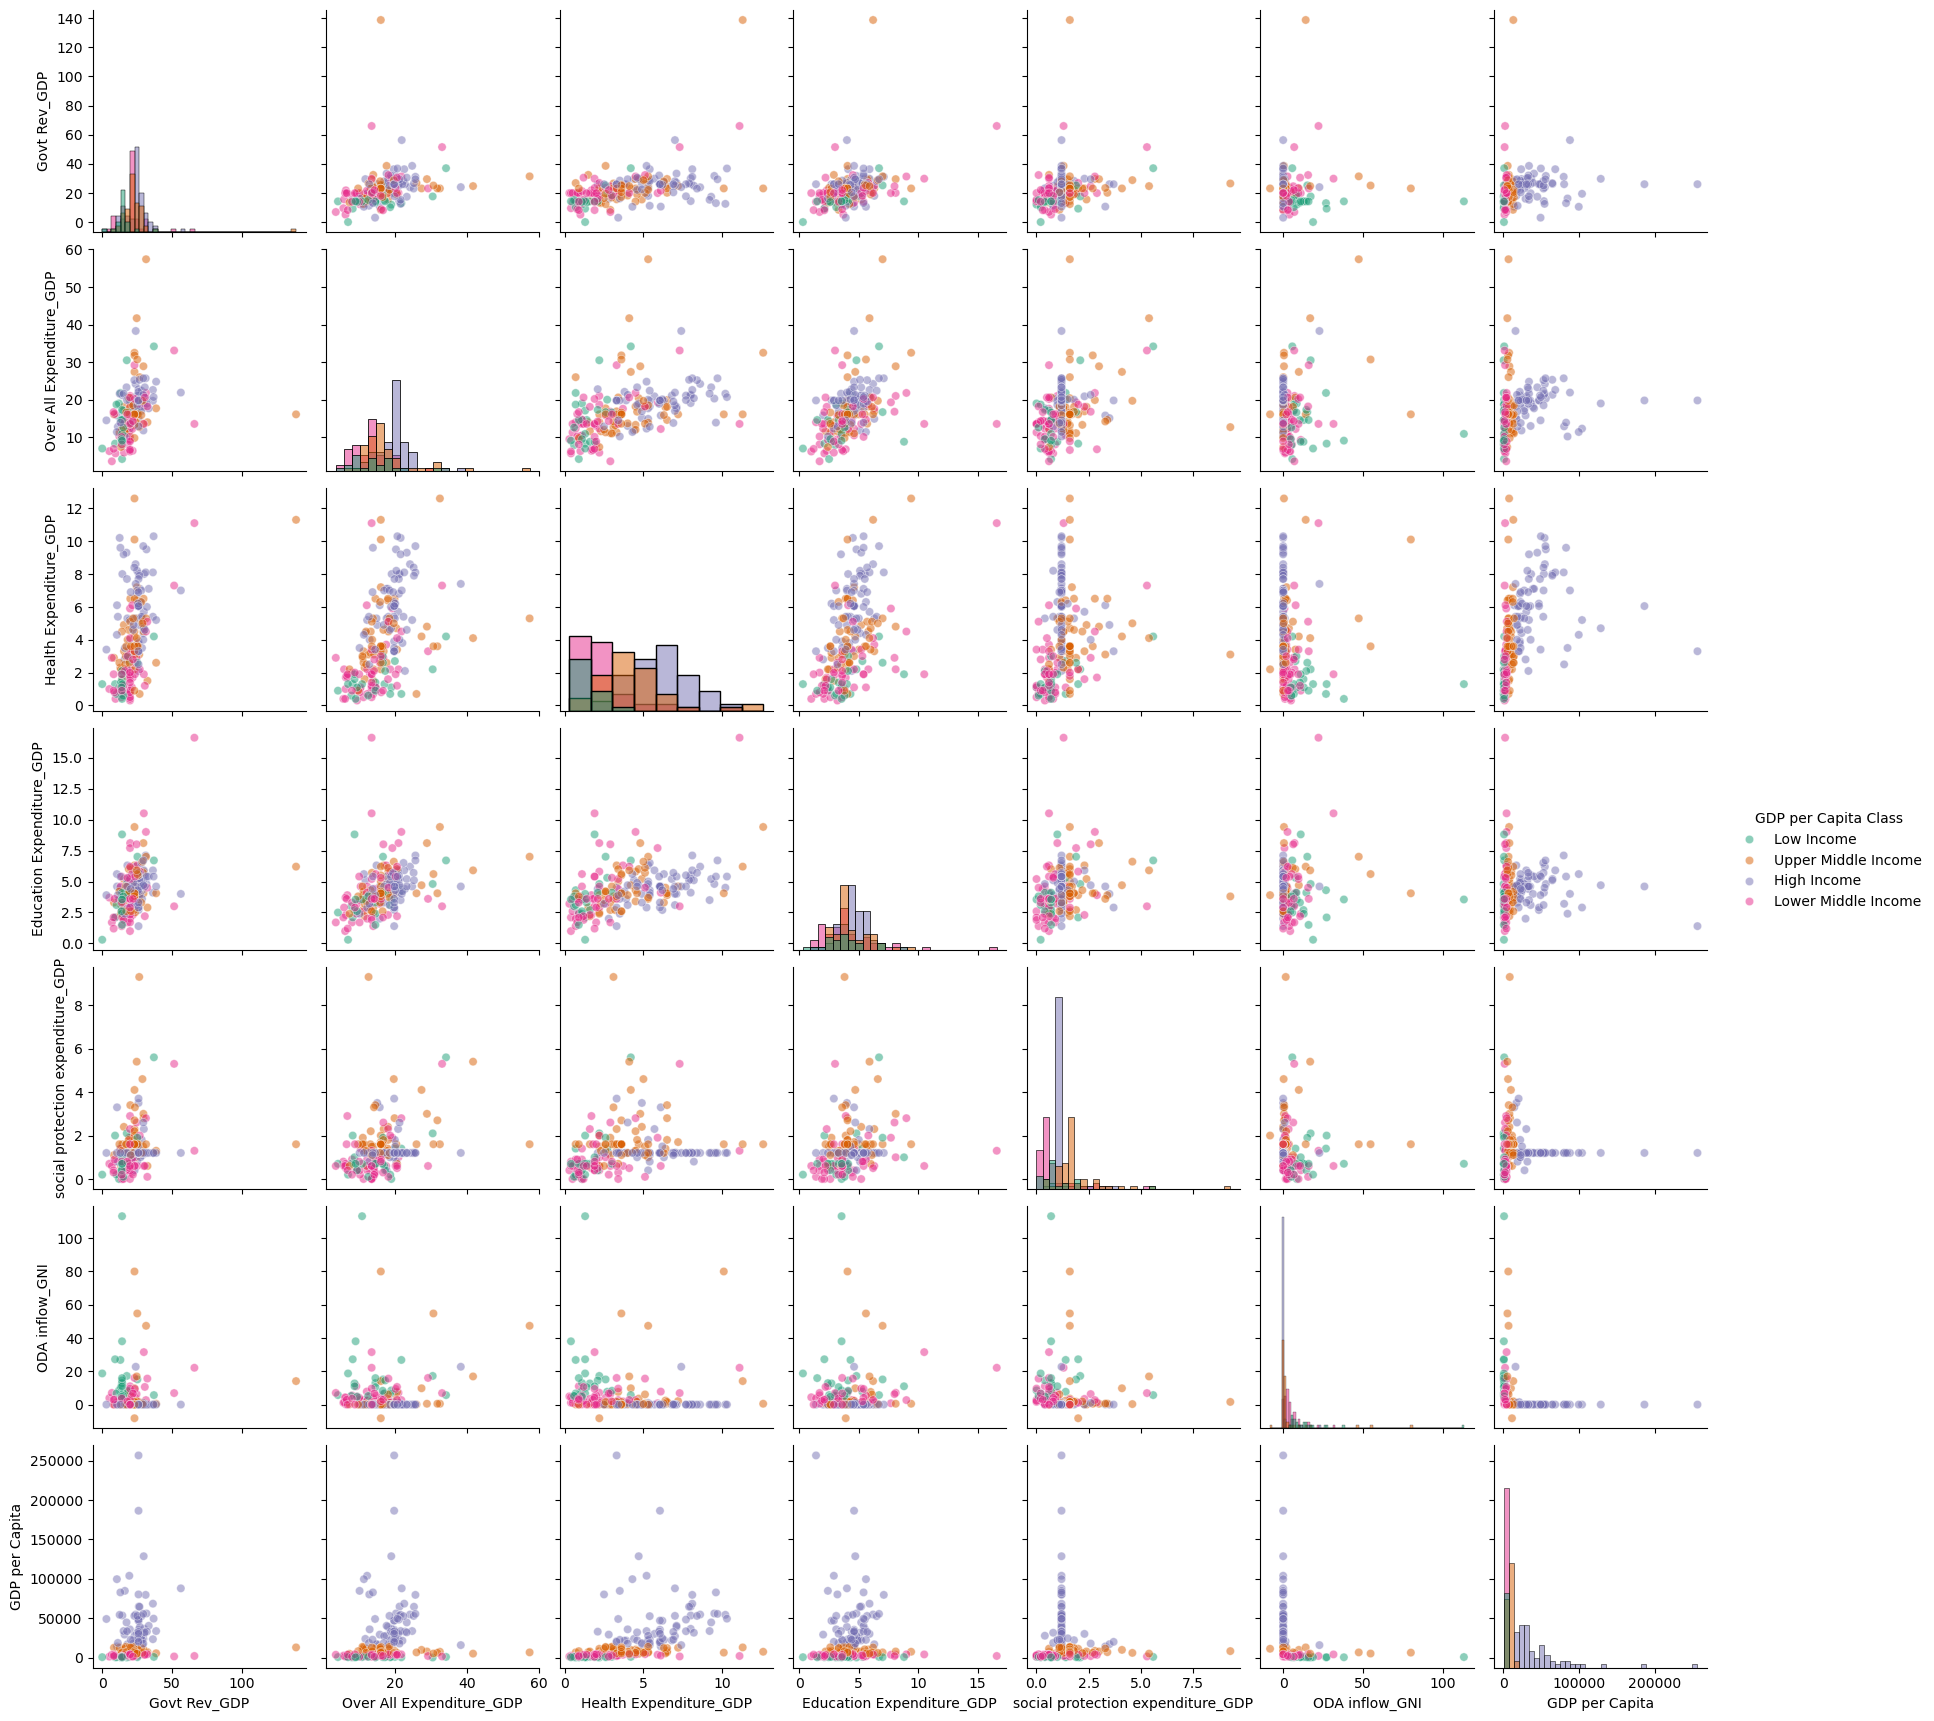

In [12]:

# Create pairplot of the data with the hue set to GDP per capita class
sns.pairplot(df, hue=df.columns[-1], diag_kind='hist', 
             markers='o', palette='Dark2', plot_kws={'alpha':0.5})
plt.grid(True)
plt.show()

# Linear Separation between the data points seems difficult here

Nevertheless lets try the Linear Discriminant Analysis i.e SVM

# Train Test Split the Data

In [13]:
from sklearn.model_selection import train_test_split

In [18]:
X = df.drop(['Country', 'GDP per Capita Class', 'GDP per Capita'], axis=1)
y = df['GDP per Capita Class']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

Why not Scale the data? Its always good to scale!

In [22]:
# Standardize the data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_trained_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_trained_scaled = pd.DataFrame(X_trained_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

# Train a Model by Support Vector Machine Classifier

In [25]:
# calling SVC() model from sklearn.svm
from sklearn.svm import SVC

In [26]:
# creating an object of SVC class
svc_model = SVC()

In [27]:
# fitting the model
svc_model.fit(X_trained_scaled, y_train)

SVC()

# Model Evaluation 

In [28]:
# predicting the target value
y_pred = svc_model.predict(X_test_scaled)

In [29]:
# making evaluations
from sklearn.metrics import classification_report, confusion_matrix


In [30]:
print('confusion_matrix: \n', confusion_matrix(y_test, y_pred))
print('\n')
print('classification_report: \n', classification_report(y_test, y_pred))

confusion_matrix: 
 [[ 8  0  0  6]
 [ 0  1  2  1]
 [ 0  0 14  3]
 [ 2  0  1 13]]


classification_report: 
                      precision    recall  f1-score   support

        High Income       0.80      0.57      0.67        14
         Low Income       1.00      0.25      0.40         4
Lower Middle Income       0.82      0.82      0.82        17
Upper Middle Income       0.57      0.81      0.67        16

           accuracy                           0.71        51
          macro avg       0.80      0.61      0.64        51
       weighted avg       0.75      0.71      0.70        51



# Accuracy is of 71% for classifying this data into 4 classes

Can we do hyperparameter tuning?

In [31]:
#hyperparameter tuning
from sklearn.model_selection import GridSearchCV
# defining parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf','poly']}
# Now do Grid Search
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
# fitting the model for grid search
grid.fit(X_trained_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.355 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.367 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.367 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.367 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.367 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.548 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.600 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.667 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.600 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.733 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.355 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'poly']},
             verbose=3)

In [32]:
# Finding the best parameters
print('best parameters: ', grid.best_params_)
print('\n')
print('best estimator: ', grid.best_estimator_)
print('\n')
print('best score: ', grid.best_score_)
print('\n')

best parameters:  {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}


best estimator:  SVC(C=10, gamma=0.1)


best score:  0.6696774193548387




In [33]:
# Refitting the model with the best parameters
grid_predictions = grid.predict(X_test_scaled) 
# Grid_predictions is the predictions made with the best parameters

In [34]:
#Evaluating the best model
print('confusion_matrix: \n', confusion_matrix(y_test, grid_predictions))
print('\n')
print('classification_report: \n', classification_report(y_test, grid_predictions))

confusion_matrix: 
 [[ 8  0  0  6]
 [ 0  2  1  1]
 [ 0  3 12  2]
 [ 4  1  3  8]]


classification_report: 
                      precision    recall  f1-score   support

        High Income       0.67      0.57      0.62        14
         Low Income       0.33      0.50      0.40         4
Lower Middle Income       0.75      0.71      0.73        17
Upper Middle Income       0.47      0.50      0.48        16

           accuracy                           0.59        51
          macro avg       0.56      0.57      0.56        51
       weighted avg       0.61      0.59      0.59        51



# Wow we got even a lower accuracy of 59% after hyperparameter tuning. 
May be our system by default is working better in this case. Its mind boggling.
Can we check the parameters by ourself? Using Elbow method? Lets see if there is any respite.

Lets take gamma = 0.1, kernel = rbf and just vary values of C from C = 1 to C = 1000

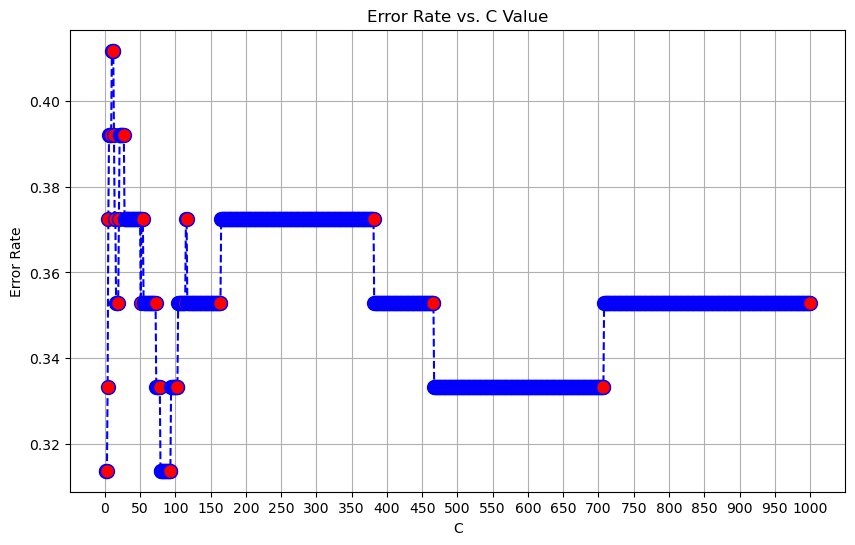

In [37]:
error_rate = []
for i in range(1,1001):

    model = SVC(gamma = 0.1, C = i, kernel='rbf')
    model.fit(X_trained_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    error_rate.append(np.mean(predictions != y_test))
# Plotting the error rate
plt.figure(figsize=(10,6))
plt.plot(range(1,1001), error_rate, color='blue', linestyle='--', marker='o', markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. C Value')
plt.xlabel('C')
plt.ylabel('Error Rate')
plt.xticks(np.arange(0, 1001, step=50))
plt.grid(True)
plt.show()

In [38]:
# Lets consider the C value to be 98
model = SVC(gamma = 0.1, C = 98, kernel='rbf')
model.fit(X_trained_scaled, y_train)
predictions = model.predict(X_test_scaled)
print('confusion_matrix: \n', confusion_matrix(y_test, predictions))
print('\n')
print('classification_report: \n', classification_report(y_test, predictions))

confusion_matrix: 
 [[10  0  0  4]
 [ 0  3  1  0]
 [ 0  3 12  2]
 [ 3  1  3  9]]


classification_report: 
                      precision    recall  f1-score   support

        High Income       0.77      0.71      0.74        14
         Low Income       0.43      0.75      0.55         4
Lower Middle Income       0.75      0.71      0.73        17
Upper Middle Income       0.60      0.56      0.58        16

           accuracy                           0.67        51
          macro avg       0.64      0.68      0.65        51
       weighted avg       0.68      0.67      0.67        51



# Thus even by Elbow method we could not do much better with Accuracy of 67%

A standard Support Vector Machine (SVM) will not perform well when data is not linearly separable, as it is designed to find a linear decision boundary, meaning it can only effectively separate classes with a straight line

# If you cant change the Accuracy, then change the Target Variable :P
Lets try clubbing the Countries into two classes
1. Low Income ( Low Income, Lower Middle Income)
2. High Income( High Income, Upper Middle Income)

In [39]:
# Clubbing data of 'Low Income' and 'Lower Middle Income' into one class
# Clubbing data of 'Upper Middle Income' and 'High Income' into one class
df['GDP per Capita Class'] = df['GDP per Capita Class'].replace(['Low Income', 'Lower Middle Income'], 'Low Income')
df['GDP per Capita Class'] = df['GDP per Capita Class'].replace(['Upper Middle Income', 'High Income'], 'High Income')

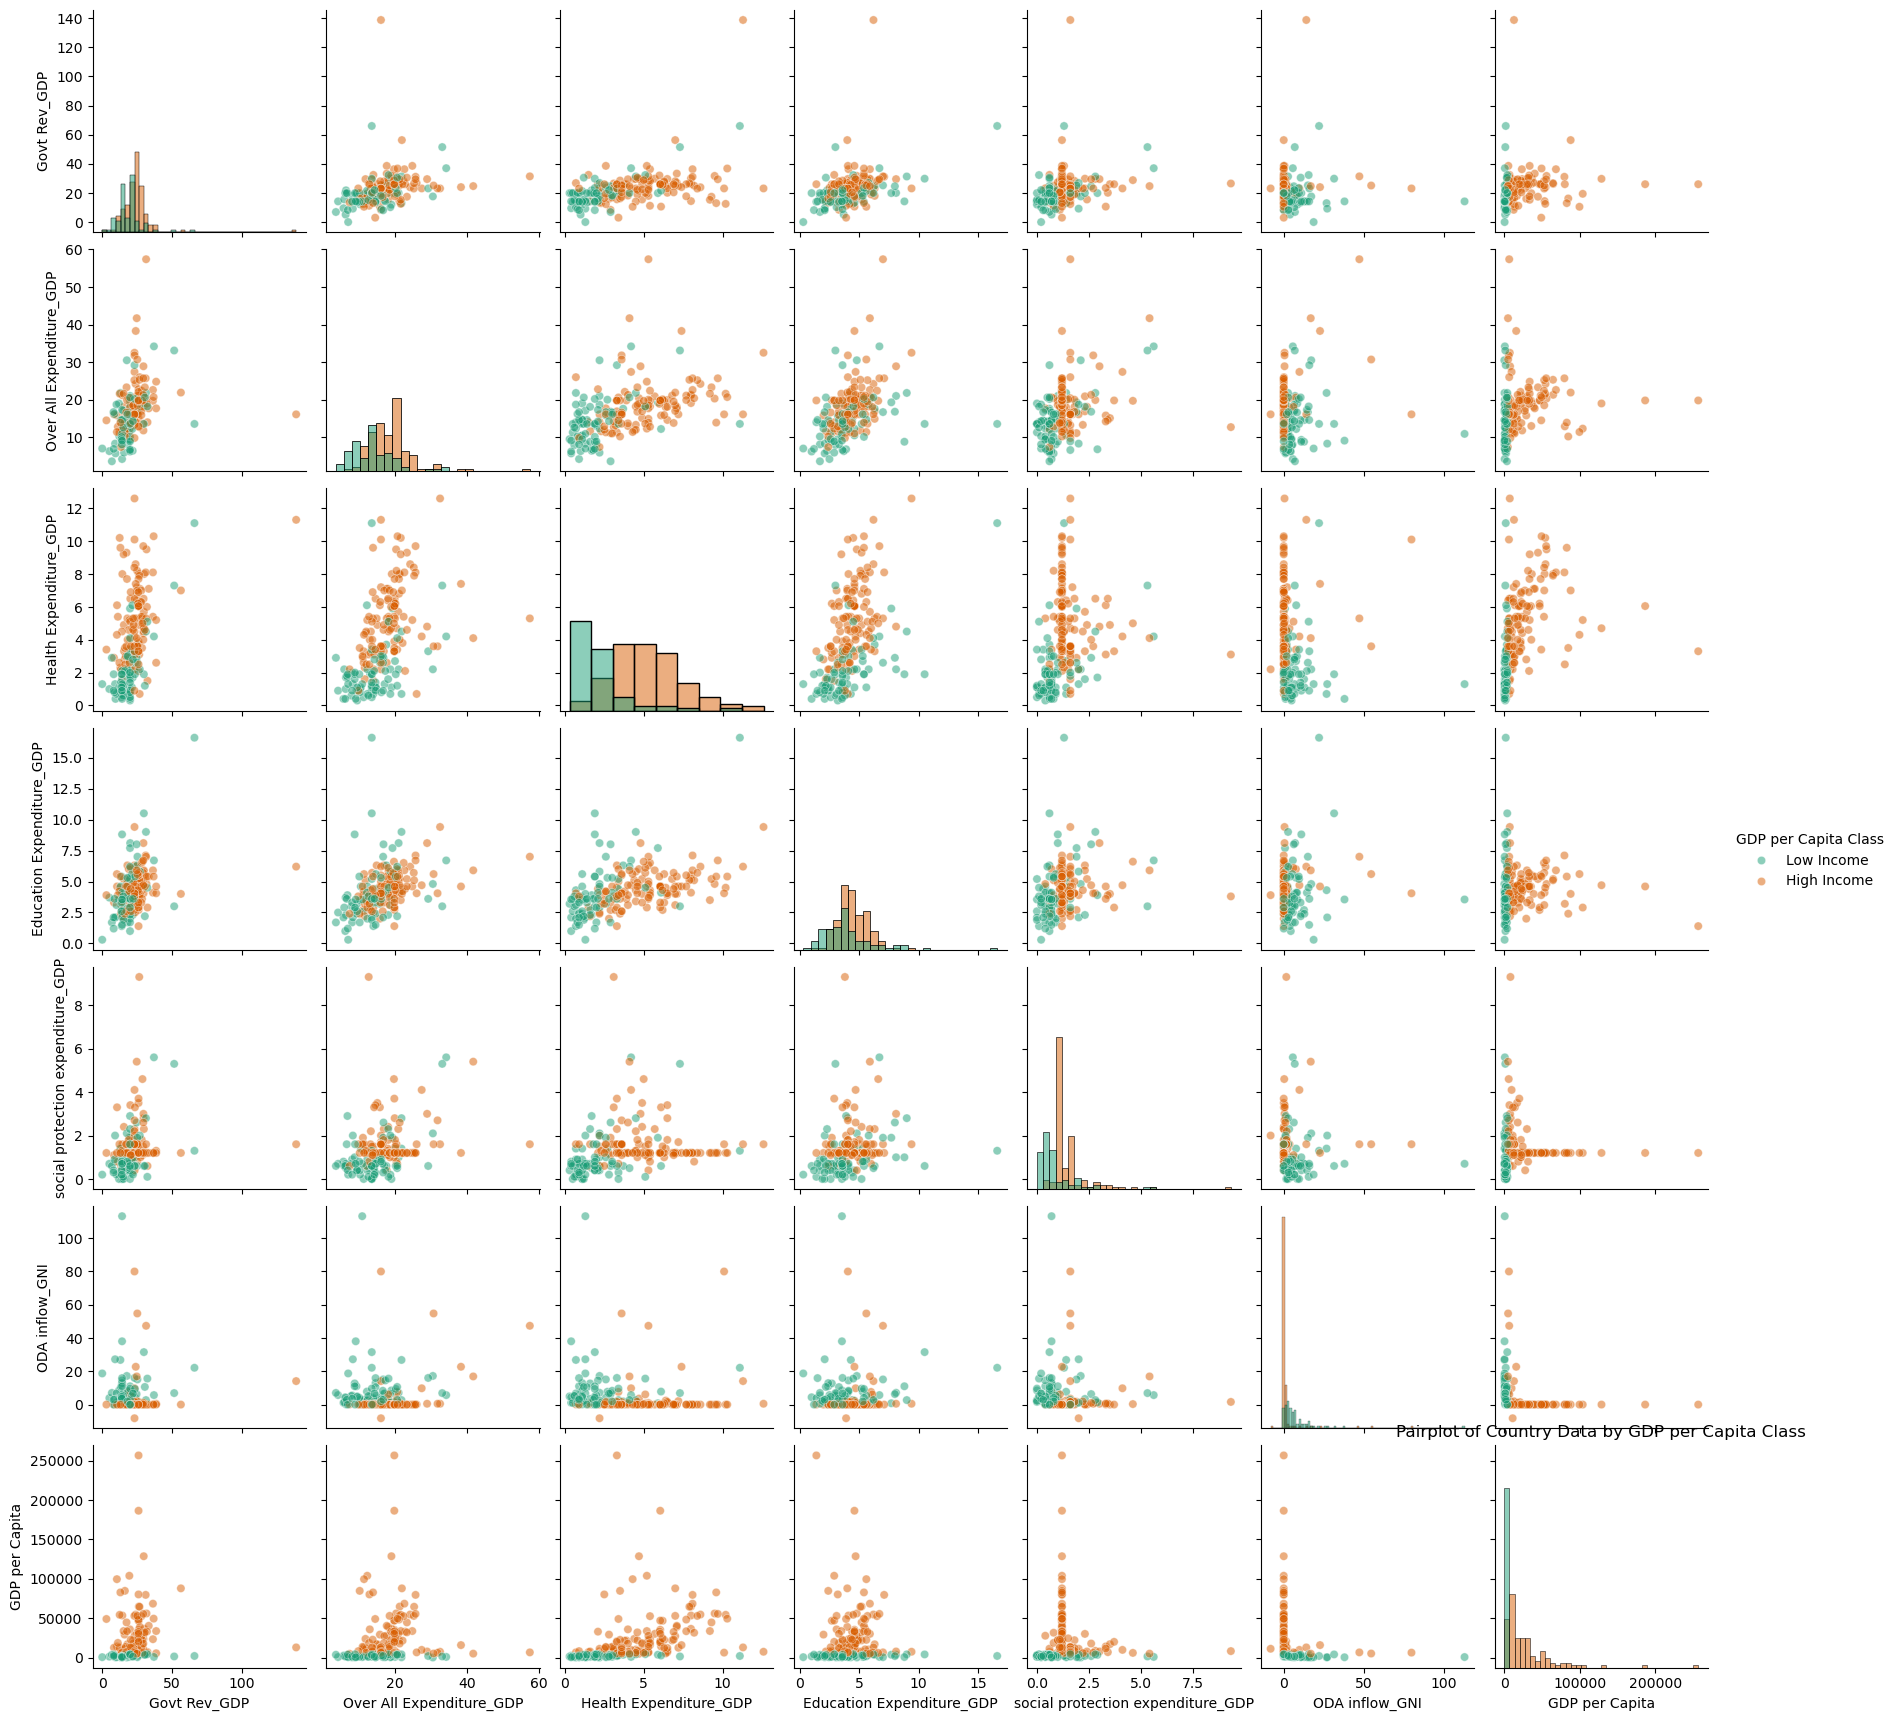

In [40]:
# Lets do a pairplot of the data with the hue set to GDP per capita class again
sns.pairplot(df, hue=df.columns[-1], diag_kind='hist', 
             markers='o', palette='Dark2', plot_kws={'alpha':0.5})
plt.grid(True)
plt.title('Pairplot of Country Data by GDP per Capita Class')
plt.show()

# What a respite to see a degree of Linear Separation in the data from the scatterplots

Probably SVM can do better now

In [41]:
# Splitting the data into features and target
X = df.drop(['Country', 'GDP per Capita Class', 'GDP per Capita'], axis=1)
y = df['GDP per Capita Class']

In [42]:
# Splitting the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [43]:
# Standardizing the data
scaler = StandardScaler()
X_trained_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [44]:
# Converting the numpy array to a pandas dataframe
X_trained_scaled = pd.DataFrame(X_trained_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [45]:
# Initializing the model
svc_model = SVC()

In [46]:
# Fitting the model
svc_model.fit(X_trained_scaled, y_train)

SVC()

In [47]:
# Predicting the target value
y_pred = svc_model.predict(X_test_scaled)

In [48]:
# Evaluating the model
print('confusion_matrix: \n', confusion_matrix(y_test, y_pred))
print('\n') 
print('classification_report: \n', classification_report(y_test, y_pred))

confusion_matrix: 
 [[29  1]
 [ 5 16]]


classification_report: 
               precision    recall  f1-score   support

 High Income       0.85      0.97      0.91        30
  Low Income       0.94      0.76      0.84        21

    accuracy                           0.88        51
   macro avg       0.90      0.86      0.87        51
weighted avg       0.89      0.88      0.88        51



In [49]:
# Can we do better? Lets do hyperparameter tuning
# Defining the parameter range
param_grid = {'C': [0.1, 1, 10, 100, 1000], 
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf','poly']}
# Doing Grid Search
grid = GridSearchCV(SVC(), param_grid, refit=True, verbose=3)
# Fitting the model for grid search
grid.fit(X_trained_scaled, y_train)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.613 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.600 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.633 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.667 total time=   0.0s
[CV 1/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.871 total time=   0.0s
[CV 2/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.833 total time=   0.0s
[CV 3/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.867 total time=   0.0s
[CV 4/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.833 total time=   0.0s
[CV 5/5] END .......C=0.1, gamma=1, kernel=poly;, score=0.933 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.903 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf

GridSearchCV(estimator=SVC(),
             param_grid={'C': [0.1, 1, 10, 100, 1000],
                         'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
                         'kernel': ['rbf', 'poly']},
             verbose=3)

In [50]:
# Finding the best parameters
print('best parameters: ', grid.best_params_)
print('\n')
print('best estimator: ', grid.best_estimator_)
print('\n')
print('best score: ', grid.best_score_)

best parameters:  {'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}


best estimator:  SVC(C=100, gamma=0.01)


best score:  0.8937634408602151


In [51]:
#Lets make predictions from best parameters
grid_predictions = grid.predict(X_test_scaled)


In [52]:
# Evaluating the best model
print('confusion_matrix: \n', confusion_matrix(y_test, grid_predictions))
print('\n')
print('classification_report: \n', classification_report(y_test, grid_predictions))

confusion_matrix: 
 [[28  2]
 [ 3 18]]


classification_report: 
               precision    recall  f1-score   support

 High Income       0.90      0.93      0.92        30
  Low Income       0.90      0.86      0.88        21

    accuracy                           0.90        51
   macro avg       0.90      0.90      0.90        51
weighted avg       0.90      0.90      0.90        51



# So Caeser crossed the Rubicon with an accuracy of 90%.
and there was no turning back from here :D